In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
df= pd.read_csv("Ice_cream selling data.csv")

In [9]:
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [10]:
import seaborn as sns


<Axes: xlabel='Ice Cream Sales (units)', ylabel='Count'>

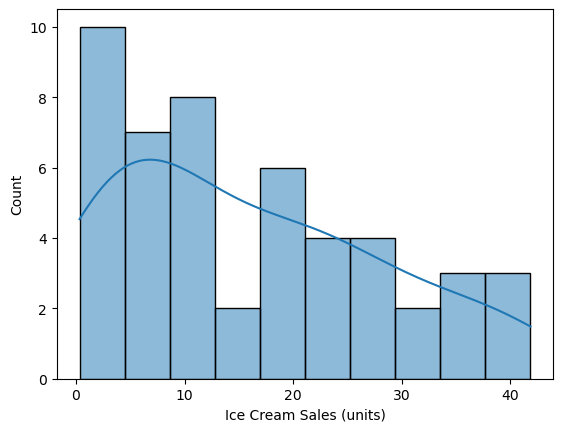

In [17]:
sns.histplot(df,x="Ice Cream Sales (units)", kde=True,bins=10)

In [14]:
sns.histplot?

Signature:
sns.histplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    weights=None,
    stat='count',
    bins='auto',
    binwidth=None,
    binrange=None,
    discrete=None,
    cumulative=False,
    common_bins=True,
    common_norm=True,
    multiple='layer',
    element='bars',
    fill=True,
    shrink=1,
    kde=False,
    kde_kws=None,
    line_kws=None,
    thresh=0,
    pthresh=None,
    pmax=None,
    cbar=False,
    cbar_ax=None,
    cbar_kws=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    color=None,
    log_scale=None,
    legend=True,
    ax=None,
    **kwargs,
)
Docstring:
Plot univariate or bivariate histograms to show distributions of datasets.

A histogram is a classic visualization tool that represents the distribution
of one or more variables by counting the number of observations that fall within
discrete bins.

This function can normalize the statistic computed within each bin to estimate
frequency, density or probability mas

<Axes: xlabel='Ice Cream Sales (units)', ylabel='Temperature (°C)'>

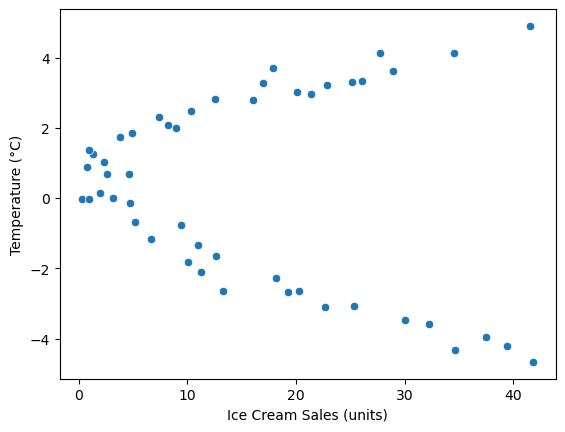

In [21]:
sns.scatterplot(df, y= "Temperature (°C)", x="Ice Cream Sales (units)")

<Axes: xlabel='Ice Cream Sales (units)', ylabel='Temperature (°C)'>

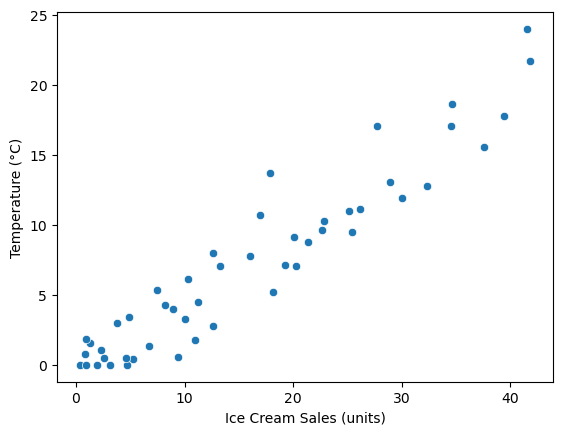

In [22]:
sns.scatterplot(y= df["Temperature (°C)"]*df["Temperature (°C)"], x=df["Ice Cream Sales (units)"])


In [23]:
x=df[["Temperature (°C)"]]
y=df[["Ice Cream Sales (units)"]]

In [25]:
x_train,x_test, y_train, y_test=train_test_split(x,y,test_size=0.4, random_state=42)

In [28]:
from sklearn.preprocessing import PolynomialFeatures 

In [31]:
poly= PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)
print(x_train_poly)
x_test_poly= poly.transform(x_test)
print(x_test_poly)

[[ 1.00000000e+00 -2.65228679e+00  7.03462523e+00]
 [ 1.00000000e+00 -1.17312327e+00  1.37621820e+00]
 [ 1.00000000e+00  6.88780908e-01  4.74419139e-01]
 [ 1.00000000e+00  2.07510060e+00  4.30604249e+00]
 [ 1.00000000e+00  1.74000001e+00  3.02760004e+00]
 [ 1.00000000e+00 -4.66226268e+00  2.17366933e+01]
 [ 1.00000000e+00  3.33593241e+00  1.11284451e+01]
 [ 1.00000000e+00  1.99931037e+00  3.99724195e+00]
 [ 1.00000000e+00 -3.45571170e+00  1.19419433e+01]
 [ 1.00000000e+00  1.35981267e+00  1.84909051e+00]
 [ 1.00000000e+00 -2.28826400e+00  5.23615213e+00]
 [ 1.00000000e+00  2.78483646e+00  7.75531413e+00]
 [ 1.00000000e+00 -4.31655945e+00  1.86326855e+01]
 [ 1.00000000e+00 -3.38952856e-02  1.14889038e-03]
 [ 1.00000000e+00 -4.21398476e+00  1.77576676e+01]
 [ 1.00000000e+00  2.83176021e+00  8.01886589e+00]
 [ 1.00000000e+00  2.47194600e+00  6.11051701e+00]
 [ 1.00000000e+00  1.49244574e-01  2.22739429e-02]
 [ 1.00000000e+00  3.02087431e+00  9.12568162e+00]
 [ 1.00000000e+00 -2.65149803e+

In [38]:
model = LinearRegression()
model.fit(x_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:

y_pred_poly= model.predict(x_test_poly)
print(mean_absolute_error(y_test, y_pred_poly))
print(mean_squared_error(y_test, y_pred_poly))
print(r2_score(y_test, y_pred_poly))


3.029598342300651
12.258730329998226
0.9011961214647716


In [41]:
print(model.coef_)
print(model.intercept_)

[[ 0.         -0.592001    1.83572621]]
[2.73928184]
